# **Text Preprocessing: Gobis Suroboyo**

### **Import Library**

In [ ]:
!pip install Sastrawi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import string
import re

# Konfigurasi tampilan
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)

### **Import Dataset**

In [ ]:
# Memuat dataset hasil EDA
file_path = 'eda_data_gobis.csv'
df_gobis = pd.read_csv(file_path, low_memory=False)

print(f'✅ Dataset Gobis Suroboyo berhasil dimuat!')
display(df_gobis.head())

✅ Dataset Gobis Suroboyo berhasil dimuat!


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,year
0,7a6008f5-0fbf-4d6d-8daf-c3942feef6bc,Aditya Rizaldy Bahren,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi thaekk🥺😭,1,0,11,2026-04-22 16:19:52,NaN,NaN,11,2026
1,169a8f87-5f99-4c49-a152-17daceea4e59,oceanasky,https://play-lh.googleusercontent.com/a-/ALV-U...,TIDAK BISA LOGIN.,1,0,NaN,2026-04-22 07:53:42,NaN,NaN,NaN,2026
2,153915b0-881f-455e-8e64-fa7510b79aa6,Alfnn Cndr,https://play-lh.googleusercontent.com/a-/ALV-U...,"perlu banyak perbaikan di aplikasi ini, inform...",1,0,11,2026-04-21 15:57:20,NaN,NaN,11,2026
3,6afd2255-b9df-4f8d-871f-7396ee9e6a3f,Gatot Wage,https://play-lh.googleusercontent.com/a/ACg8oc...,map nya gk akurat,1,0,11,2026-04-20 21:26:23,NaN,NaN,11,2026
4,235fe82d-8ce3-471f-bc89-1be6bcf7975d,Zulfikar Anggoro,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus.,5,0,11,2026-04-17 06:23:08,NaN,NaN,11,2026


### **Pengambilan Kolom Relevan**

In [ ]:
# Memilih kolom yang relevan untuk diproses teksnya
df_gobis = df_gobis.loc[:, ["content", "score", "at"]].copy()

print("✅ Kolom berhasil disaring!")
df_gobis.info()
display(df_gobis.head())

✅ Kolom berhasil disaring!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  1312 non-null   object
 1   score    1312 non-null   int64 
 2   at       1312 non-null   object
dtypes: int64(1), object(2)
memory usage: 30.9+ KB


,content,score,at
0,aplikasi thaekk🥺😭,1,2026-04-22 16:19:52
1,TIDAK BISA LOGIN.,1,2026-04-22 07:53:42
2,"perlu banyak perbaikan di aplikasi ini, inform...",1,2026-04-21 15:57:20
3,map nya gk akurat,1,2026-04-20 21:26:23
4,bagus.,5,2026-04-17 06:23:08


### **Text Preprocessing**
Meliputi tahapan Case Folding, Cleansing, Stopword Removal, dan Stemming menggunakan library Sastrawi.

In [ ]:
# Inisiasi Sastrawi
stopword_factory = StopWordRemoverFactory()
stopword = stopword_factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def text_preprocessing(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Case Folding (huruf kecil semua)
    text = text.lower()
    
    # 2. Cleansing (Hapus tanda baca, angka, dan spasi berlebih)
    text = re.sub(r'\d+', '', text) # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip() # hapus spasi ekstra
    
    # 3. Stopword Removal (Hapus kata hubung/tidak penting)
    text = stopword.remove(text)
    
    # 4. Stemming (Mengubah kata imbuhan ke bentuk dasar)
    text = stemmer.stem(text)
    
    return text

print("⏳ Memulai proses Text Preprocessing... (Mungkin memakan waktu beberapa menit karena proses stemming)\n")
df_gobis['content_clean'] = df_gobis['content'].apply(text_preprocessing)
print("✅ Proses Text Preprocessing Selesai!")
display(df_gobis[['content', 'content_clean']].head())

⏳ Memulai proses Text Preprocessing... (Mungkin memakan waktu beberapa menit karena proses stemming)

✅ Proses Text Preprocessing Selesai!


,content,content_clean
0,aplikasi thaekk🥺😭,aplikasi thaekk
1,TIDAK BISA LOGIN.,bisa login
2,"perlu banyak perbaikan di aplikasi ini, inform...",perlu banyak baik aplikasi informasi detail sa...
3,map nya gk akurat,map nya gk akurat
4,bagus.,bagus


### **Menghitung Frekuensi Kata (Word Count)**

📊 Top 20 Kata Terbanyak di Ulasan Gobis Suroboyo:


,Kata,Frekuensi
0,aplikasi,356
1,bus,342
2,nya,214
3,gak,176
4,sangat,168
5,halte,155
6,bis,152
7,yg,149
8,baik,137
9,mau,128


C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_17880\3567240633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_frekuensi, x='Frekuensi', y='Kata', palette='viridis')


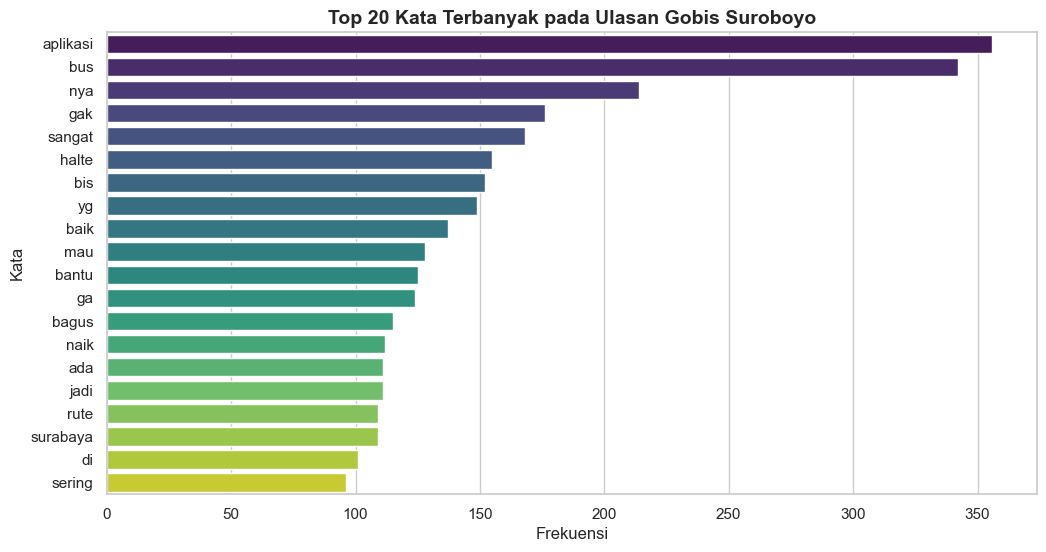

In [ ]:
# Menggabungkan semua teks bersih menjadi satu kesatuan string
semua_teks = " ".join(df_gobis['content_clean'].astype(str))

# Menghitung frekuensi kata menggunakan Counter
kata_kata = semua_teks.split()
frekuensi_kata = Counter(kata_kata)

# Membuat DataFrame top 20 kata terbanyak
df_frekuensi = pd.DataFrame(frekuensi_kata.most_common(20), columns=['Kata', 'Frekuensi'])

print("📊 Top 20 Kata Terbanyak di Ulasan Gobis Suroboyo:")
display(df_frekuensi)

# Visualisasi Frekuensi Kata
plt.figure(figsize=(12, 6))
sns.barplot(data=df_frekuensi, x='Frekuensi', y='Kata', palette='viridis')
plt.title('Top 20 Kata Terbanyak pada Ulasan Gobis Suroboyo', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

### **Menyimpan Data Preprocessed**

In [ ]:
# Hapus baris data yang content_clean nya kosong (karena hanya berisi tanda baca/stopword yang terhapus sepenuhnya)
df_gobis = df_gobis[df_gobis['content_clean'] != '']
df_gobis = df_gobis.dropna(subset=['content_clean'])

output_path = 'cleandata_gobis.csv'
df_gobis.to_csv(output_path, index=False, encoding='utf-8')

print(f'✅ Data berhasil disimpan ke: {output_path}')
print(f'   Jumlah baris : {len(df_gobis):,}')
print(f'   Jumlah kolom : {df_gobis.shape[1]}')

✅ Data berhasil disimpan ke: cleandata_gobis.csv
   Jumlah baris : 1,288
   Jumlah kolom : 4
